In [ ]:
import random
import math
import numpy as np
import torch

In [ ]:
int(random.uniform(-2,2))

1

In [ ]:
X = [255, 0, 128]

In [ ]:
W = [random.uniform(-1, 1) for i in range(3)]
print(W)

[-0.17892298808324236, 0.32837748989169024, 0.7009851595389778]


In [ ]:
b = random.uniform(-1, 1)
print(b)

-0.002326365320643342


In [ ]:
sum1 = 0
for i in range(3):
  sum1 += X[i] * W[i]
sum1 += b
sum1

44.09841209444171

## Class Neuron

In [ ]:
# random.seed(42)
class Neuron():
  def __init__(self, num_inputs):
    self.num_inputs = num_inputs
    self.weights = [torch.tensor(random.uniform(-1, 1), requires_grad=True) for i in range(num_inputs)]
    self.bias = torch.tensor(random.uniform(-1, 1), requires_grad=True)

  def __call__(self, inputs):
    return sum([inputs[i] * self.weights[i] for i in range(self.num_inputs)]) + self.bias # update

  def parameters(self):
    return self.weights + [self.bias]



neuron1 = Neuron(3)
X = [1.0, 2.0, 3.0] # input
neuron1(X)

tensor(-0.6363, grad_fn=<AddBackward0>)

## Class Layer

In [ ]:
random.seed(42)
class Layer():
  def __init__(self, num_inputs, num_neurons):
    self.neurons = [Neuron(num_inputs) for i in range(num_neurons)]

  def __call__(self, inputs):
    return [neuron(inputs) for neuron in self.neurons]

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]



X = [1.0, 2.0, 3.0] # input
layer = Layer(3, 4)
layer(X)

[tensor(-3.5245, grad_fn=<AddBackward0>),
 tensor(2.7067, grad_fn=<AddBackward0>),
 tensor(-3.7144, grad_fn=<AddBackward0>),
 tensor(-1.1624, grad_fn=<AddBackward0>)]

## Class MLP

In [ ]:
class MLP():
  def __init__(self, num_inputs, layers_sizes):
    self.tmp = layers_sizes[-1]
    sizes = [num_inputs] + layers_sizes # [3, 4, 4, 1]
    self.layers = [Layer(sizes[i], sizes[i+1]) for i in range(len(sizes) - 1)]


  def __call__(self, inputs):
    x = inputs
    for layer in self.layers:
      x = layer(x)
    return x[0] if self.tmp == 1 else x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]





X = [1.0, 2.0, 3.0] # input
mlp = MLP(3, [4, 4, 1])
mlp(X)

tensor(-1.7099, grad_fn=<AddBackward0>)

## EvapoTranspirtation Prediction

In [ ]:
import numpy as np
import pandas as pd
import math

def generate_et_dataset(n=1_000_000, seed=42):
    """
    Generate a synthetic dataset of weather features with ET as the target.

    Features:
        avgtemp_c, maxtemp_c, mintemp_c, avgwind_kph, avghumidity, sunHour
    Target:
        et (mm/day) — computed via Penman-Monteith
    """
    rng = np.random.default_rng(seed)

    # --- Generate realistic weather features ---
    avgtemp_c   = rng.uniform(-5, 45, n)                          # °C
    temp_spread = rng.uniform(2, 12, n)                            # max-min range
    mintemp_c   = avgtemp_c - temp_spread * rng.uniform(0.3, 0.6, n)
    maxtemp_c   = avgtemp_c + temp_spread * rng.uniform(0.4, 0.7, n)
    avgwind_kph = rng.uniform(2, 50, n)                            # km/h
    avghumidity = rng.uniform(10, 100, n)                          # %
    sunHour     = rng.uniform(0.5, 14, n)                          # hours

    # --- Vectorised ET calculation (mirrors the notebook functions) ---
    # 1) Solar radiation  (calculate_solar_radiation logic)
    tmax_k = maxtemp_c + 273.15
    tmin_k = mintemp_c + 273.15
    albedo = 0.23
    altitude = 0
    ea_const = 2.5
    sigma = 4.903e-9

    total_solar = sunHour * 0.2 * 4.92
    rso = (0.75 + 2e-5 * altitude) * total_solar
    # Avoid division by zero where rso might be tiny
    ratio = np.clip(total_solar / np.where(rso == 0, 1e-9, rso), 0, 1.5)
    rl = (sigma * ((tmax_k**4 + tmin_k**4) / 2)
          * (0.34 - 0.14 * np.sqrt(ea_const))
          * (1.35 * ratio - 0.35))
    solar_radiation = (1 - albedo) * total_solar - rl

    # 2) Penman-Monteith ET  (calculate_et logic)
    temp = avgtemp_c
    humidity = avghumidity
    wind_speed_ms = avgwind_kph / 3.6          # convert km/h → m/s

    L = 2.45
    cp = 1.013e-3
    epsilon = 0.622
    pressure = 101.3 * ((293 - 0.0065 * altitude) / 293) ** 5.26

    es = 0.6108 * np.exp((17.27 * temp) / (temp + 237.3))
    ea = es * (humidity / 100)
    delta = (4098 * es) / ((temp + 237.3) ** 2)
    gamma = (cp * pressure) / (epsilon * L)

    Rn = solar_radiation * 0.77
    u2 = wind_speed_ms * (4.87 / np.log(67.8 * 2 - 5.42))

    et = ((0.408 * delta * Rn + gamma * (900 / (temp + 273)) * u2 * (es - ea))
          / (delta + gamma * (1 + 0.34 * u2)))
    et = np.round(et, 2)

    # --- Build DataFrame ---
    dataset = pd.DataFrame({
        'avgtemp_c':   np.round(avgtemp_c, 2),
        'maxtemp_c':   np.round(maxtemp_c, 2),
        'mintemp_c':   np.round(mintemp_c, 2),
        'avgwind_kph': np.round(avgwind_kph, 2),
        'avghumidity': np.round(avghumidity, 2),
        'sunHour':     np.round(sunHour, 2),
        'et':          et
    })

    return dataset

dataset = generate_et_dataset()
print(f"Shape: {dataset.shape}")
dataset.head(10)

Shape: (1000000, 7)


,avgtemp_c,maxtemp_c,mintemp_c,avgwind_kph,avghumidity,sunHour,et
0,33.70,38.37,28.77,29.03,87.73,13.17,2.30
1,16.94,19.76,13.03,12.21,77.56,2.21,0.54
2,37.93,38.95,36.89,48.67,78.71,3.87,4.29
3,29.87,33.21,27.05,36.77,52.37,9.54,7.56
4,-0.29,4.44,-3.02,12.47,10.31,6.50,2.18
5,43.78,46.78,42.17,2.90,20.50,10.90,1.91
6,33.06,39.04,29.46,32.87,33.08,12.87,11.27
7,34.30,39.90,30.23,42.62,80.63,6.91,3.48
8,1.41,8.93,-2.42,20.06,40.39,2.31,1.84
9,17.52,20.35,15.68,7.50,75.50,8.24,0.91


## Train

In [ ]:
X = dataset.drop(columns=['et'])
y = dataset['et']

In [ ]:
from sklearn.model_selection import train_test_split



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
X_train

,avgtemp_c,maxtemp_c,mintemp_c,avgwind_kph,avghumidity,sunHour
566853,38.23,43.86,33.93,21.25,12.72,1.94
382311,11.18,13.72,8.63,48.54,53.80,2.15
241519,20.36,23.76,16.24,9.24,90.63,5.99
719220,15.05,17.54,11.83,22.45,35.69,5.99
905718,42.14,47.43,36.08,36.05,61.96,3.05
...,...,...,...,...,...,...
259178,27.27,34.04,22.55,41.87,57.70,9.92
365838,10.72,15.09,6.32,2.60,38.30,3.91
131932,19.70,24.10,13.65,11.22,14.86,3.76
671155,38.09,39.65,36.78,5.41,89.37,2.42


In [ ]:
dataset['avgtemp_c'].min(), dataset['avgtemp_c'].max()

(-5.0, 45.0)

In [ ]:
dataset['avghumidity'].min(), dataset['avghumidity'].max()

(10.0, 100.0)

In [ ]:
y_train

,et
566853,10.60
382311,3.57
241519,0.15
719220,4.37
905718,7.17
...,...
259178,6.66
365838,0.32
131932,3.96
671155,-1.04


In [ ]:
batch_size = 32

# Normalize features (zero mean, unit variance)
X_mean = X_train.mean()
X_std  = X_train.std()
X_train_norm = (X_train - X_mean) / X_std
X_test_norm  = (X_test  - X_mean) / X_std

# Normalize target
y_mean = y_train.mean()
y_std  = y_train.std()
y_train_norm = (y_train - y_mean) / y_std
y_test_norm  = (y_test  - y_mean) / y_std

def get_batch(split):
  if split == 'train':
    X_data, y_data = X_train_norm, y_train_norm
  else:
    X_data, y_data = X_test_norm, y_test_norm

  randoms = [int(random.uniform(0, len(X_data))) for _ in range(batch_size)]
  X = [X_data.iloc[i].tolist() for i in randoms] # update
  y = [y_data.iloc[i].tolist() for i in randoms] # update

  X = torch.tensor(X)
  y = torch.tensor(y)

  return X, y

In [ ]:
model = MLP(6, [32, 32, 1])

In [ ]:
max_iters = 100
for i in range(max_iters):
  Xb, yb = get_batch('train')
  # 1 Calculate the prediction
  predicted = [model(input) for input in Xb]
  # 2 Calculate the loss
  loss = sum([(predicted[j] - yb[j]) ** 2 for j in range(batch_size)]) / batch_size
  # 3 backpropagation
  for p in model.parameters():
    if p.grad is not None:
      p.grad.zero_()
  loss.backward()
  # 4 Gradient Descent
  with torch.no_grad():
    for p in model.parameters():
      p += -0.0001 * p.grad

  print(f"loss in iteration {i} = {loss}")

loss in iteration 0 = 243.67962646484375
loss in iteration 1 = 184.9712371826172
loss in iteration 2 = 153.63258361816406
loss in iteration 3 = 192.24606323242188
loss in iteration 4 = 138.093505859375
loss in iteration 5 = 129.81570434570312
loss in iteration 6 = 63.310115814208984
loss in iteration 7 = 73.24260711669922
loss in iteration 8 = 99.29935455322266
loss in iteration 9 = 86.845703125
loss in iteration 10 = 27.977699279785156
loss in iteration 11 = 45.32889938354492
loss in iteration 12 = 47.9741325378418
loss in iteration 13 = 33.15095901489258
loss in iteration 14 = 27.56597328186035
loss in iteration 15 = 21.188411712646484
loss in iteration 16 = 17.94853401184082
loss in iteration 17 = 14.297861099243164
loss in iteration 18 = 15.027798652648926
loss in iteration 19 = 15.462671279907227
loss in iteration 20 = 11.361266136169434
loss in iteration 21 = 14.103610038757324
loss in iteration 22 = 11.564786911010742
loss in iteration 23 = 6.188018798828125
loss in iteration 24

In [ ]:
loss

tensor(0.5344, grad_fn=<DivBackward0>)

## Compare

MAE:  0.5335
MSE:  0.4606
RMSE: 0.6787


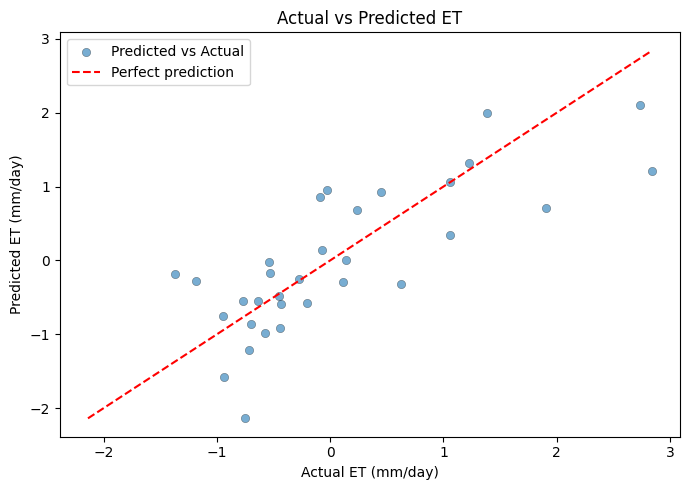

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def compare_predictions(model, split='test'):
    """
    Compare actual ET values vs model predictions for the custom MLP.
    """
    xb, yb = get_batch(split)

    # Get predictions one sample at a time (custom MLP doesn't do batch forward)
    with torch.no_grad():
        preds = [model(xb[j]).item() for j in range(len(xb))]

    actual = np.array([yb[j].item() for j in range(len(yb))])
    predicted = np.array(preds)

    # Metrics
    mae = np.mean(np.abs(actual - predicted))
    mse = np.mean((actual - predicted) ** 2)
    rmse = np.sqrt(mse)

    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

    # Plot: Actual vs Predicted scatter
    plt.figure(figsize=(7, 5))
    plt.scatter(actual, predicted, alpha=0.6, edgecolors='k', linewidths=0.3, label='Predicted vs Actual')
    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
    plt.xlabel('Actual ET (mm/day)')
    plt.ylabel('Predicted ET (mm/day)')
    plt.title('Actual vs Predicted ET')
    plt.legend()
    plt.tight_layout()
    plt.show()

compare_predictions(model)

## Using PyTorch

In [ ]:
# model = MLP(6, [32, 32, 1])

In [ ]:
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(6, 32),
    nn.ReLU(),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

In [ ]:
loss_fn = nn.MSELoss()

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [ ]:
max_iters = 1000
for i in range(max_iters):
  Xb, yb = get_batch('train')
  # 1 Calculate the prediction
  predicted = model(Xb)
  # 2 Calculate the loss
  loss = loss_fn(predicted, yb.unsqueeze(1))
  # 3 backpropagation
  optimizer.zero_grad()
  loss.backward()
  # 4 Gradient Descent
  optimizer.step()
  if i % 100 == 0:
    print(f"loss in iteration {i} = {loss}")

loss in iteration 0 = 1.35687255859375
loss in iteration 100 = 0.4299417734146118
loss in iteration 200 = 0.19046367704868317
loss in iteration 300 = 0.08424802124500275
loss in iteration 400 = 0.05267917737364769
loss in iteration 500 = 0.04666193574666977
loss in iteration 600 = 0.026769353076815605
loss in iteration 700 = 0.07608986645936966
loss in iteration 800 = 0.033144496381282806
loss in iteration 900 = 0.060994043946266174


MAE:  0.1505
MSE:  0.0418
RMSE: 0.2045


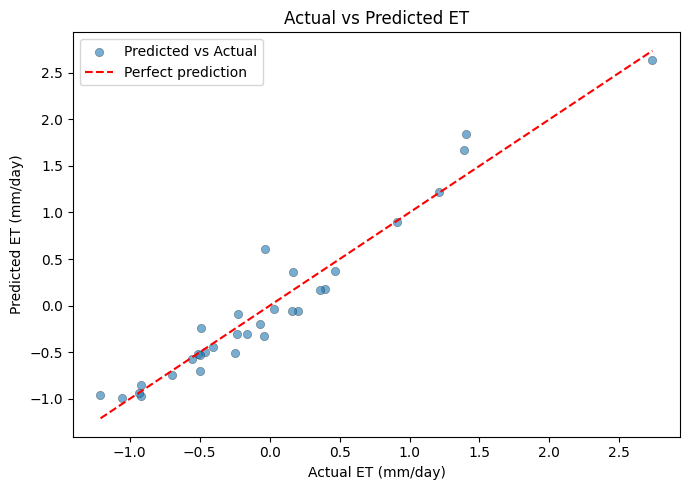

In [ ]:
compare_predictions(model)